Homework
The homework is to prepare a report for the Ministry of Transport, revealing the nature and characteristics of flight delays. The report should help identify problem areas and contribute to decision-making. Therefore, strive not to state general facts, but to show problems. For example, the fact "the average departure delay is 15 minutes" by itself says little and does not help to understand why this is happening. On the contrary, a graph showing that on Mondays delays increase threefold compared to other days against the background of an increase in the number of flights and passengers suggests a possible cause of the problem: airports cannot cope with uneven load.

The report should be in the form of a notebook with a clear structure. At the beginning of the Markdown cell there is a brief description of the question under study (what we will study), then the code and all its outputs (tables, graphs, values), then again in the Markdown cell in which your brief conclusion is formulated.

The report should contain at least 5 results confirmed by graphs. For variety of material, use different types of diagrams. All graphs should be provided with the necessary signatures (axis designations, title, color scheme legend).

To solve the problems, use the methods of the pandas library.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

flights = pd.read_csv('flights.csv', low_memory = False)
flights = flights[flights['ORIGIN_AIRPORT'].str.len() == 3]

p1 = ~flights["ORIGIN_AIRPORT"].str.isdigit()
p2 = ~flights["DESTINATION_AIRPORT"].str.isdigit()

flights = flights[p1 & p2]
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
airlines = pd.read_csv('airlines.csv', low_memory = False)
airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [4]:
airports = pd.read_csv('airports.csv', low_memory = False)
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


# 1. Попробуем понять, в каких аэропортах средняя задержка больше   

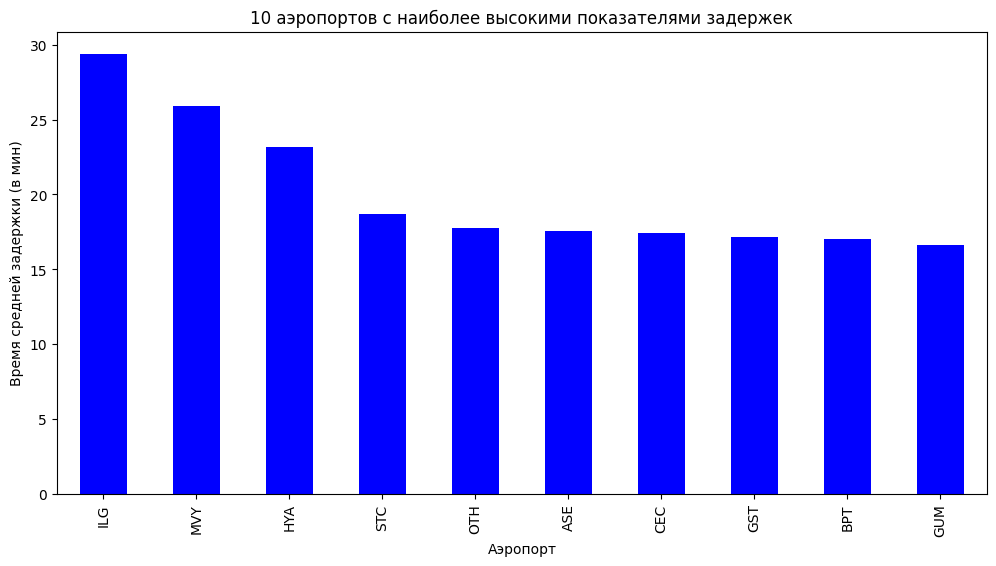

In [7]:
mea = flights.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean()
mea = mea.sort_values(ascending = False).head(10)

plt.figure(figsize = (12, 6))
mea.plot(kind = 'bar', color = 'blue')
plt.title('10 аэропортов с наиболее высокими показателями задержек')
plt.ylabel('Время средней задержки (в мин)')
plt.xlabel('Аэропорт')
plt.show()

> Мы смогли выявить 10 аэропортов с самой большой задержкой. Сильно выделяются такие аэропорты: ILG, MVY, HYA, STC. Их задержка в диапазоне от **20 до 30 минут**, что довольно много. У других же в среднем менее *15 минут*

# 2. Оценим среднюю задержку рейсов по отдельно взятым компаниям

AIRLINE
NK    16.683317
UA    15.131718
F9    14.267977
B6    11.828654
WN    10.995318
MQ    10.685483
AA     9.330882
VX     9.211211
EV     9.076964
OO     8.181225
DL     7.763099
US     6.141137
AS     1.957637
HA     0.514001
Name: DEPARTURE_DELAY, dtype: float64


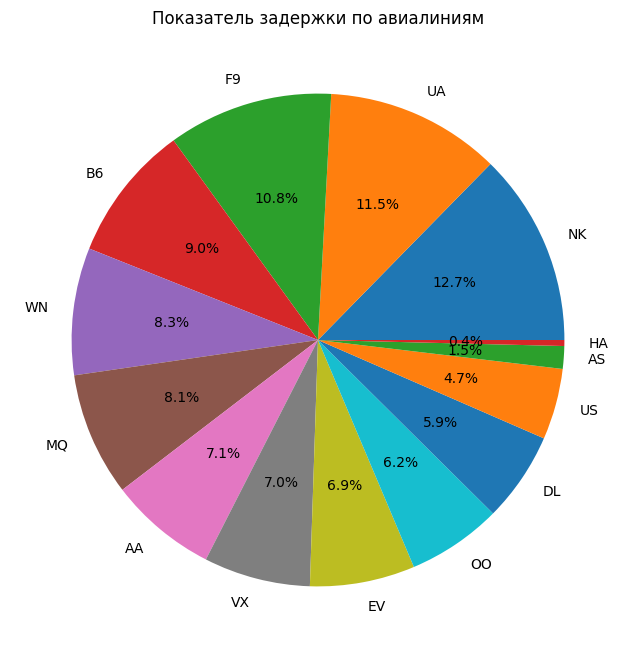

In [9]:
air = flights.groupby('AIRLINE')['DEPARTURE_DELAY'].mean()
air.sort_values(ascending = False, inplace = True)

print(air)

plt.figure(figsize = (12, 8))
plt.pie(air.values, labels = air.index, autopct = '%1.1f%%')
plt.title('Показатель задержки по авиалиниям')
plt.show()

> Можно сделать вывод, что NK, UA, F9, B6 чаще остальных компаний задерживают рейс

# 3. Определим среднюю задержку рейса в течение дня

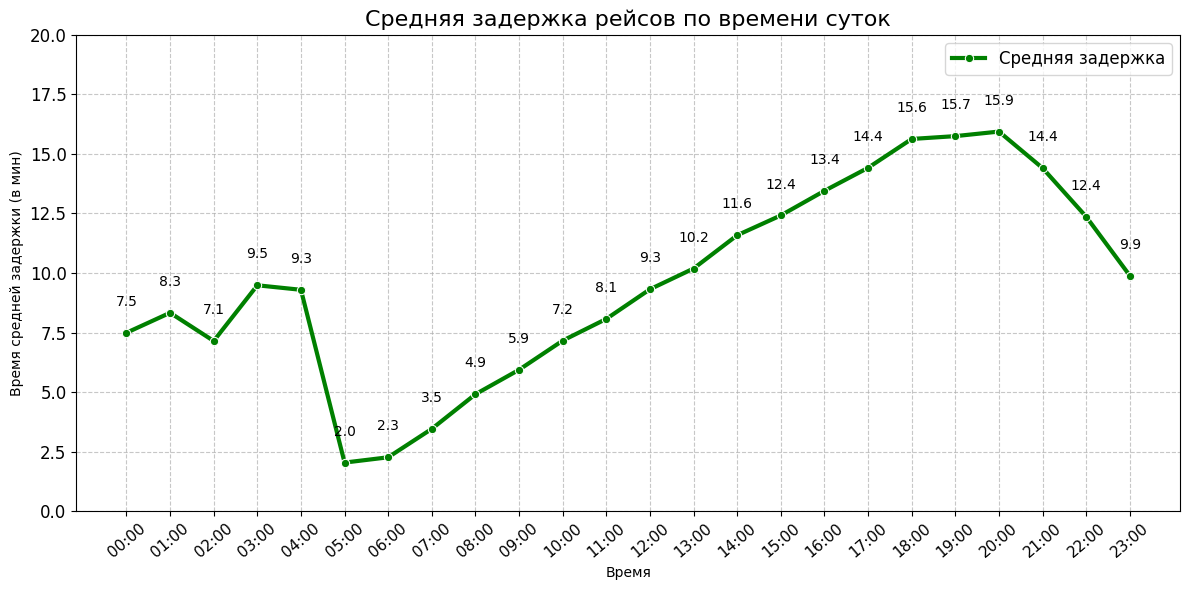

In [22]:
flights['HOUR'] = flights['SCHEDULED_DEPARTURE'] // 100

dh = flights.groupby('HOUR')['DEPARTURE_DELAY'].mean()

plt.figure(figsize = (12, 6))
sns.lineplot(x=dh.index, y=dh.values, marker='o', color='green', linewidth=3, label='Средняя задержка')

for hour, delay in zip(dh.index, dh.values):
    plt.text(hour, delay + 1, f'{delay:.1f}', ha = 'center', va = 'bottom', fontsize = 10, color = 'black')

plt.title('Средняя задержка рейсов по времени суток', fontsize = 16)
plt.xlabel('Время')
plt.ylabel('Время средней задержки (в мин)')
plt.xticks(range(24), [f'{x:02d}:00' for x in range(24)], rotation = 40, fontsize = 11)
plt.yticks(fontsize = 12)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.legend(fontsize = 12)
plt.ylim(0, 20)
plt.tight_layout()
plt.show()

> Можно заметить, что большие задержки преимущественно в вечернее время. Однако ночью они так же большие. Самое благоприятное время для вылета без задержек - 5-9 утра

# 4. Определим среднюю задержку рейса по дням недели

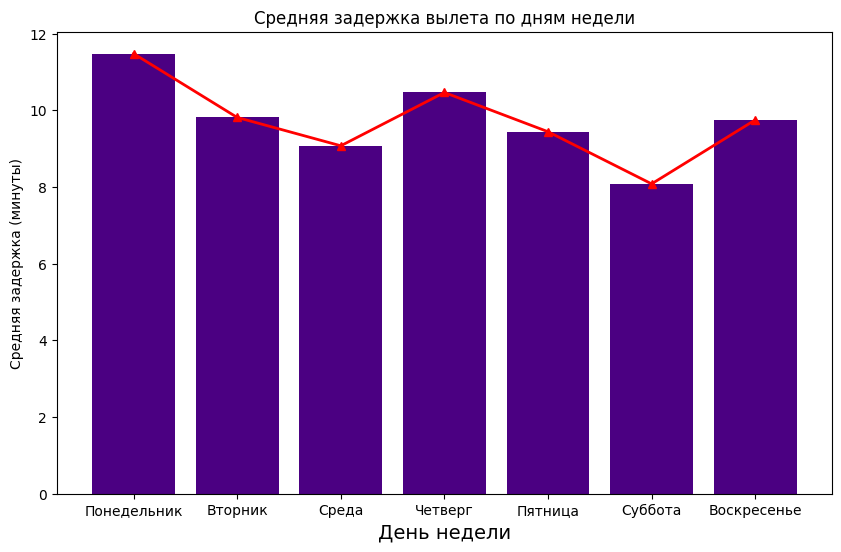

In [16]:
delays_dow = flights.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean()


dow = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

plt.figure(figsize=(10, 6))
plt.bar(dow, delays_dow.values, color='indigo')
plt.plot(dow, delays_dow.values, marker='^', color='red', linewidth=2, label='Тренд')
plt.title("Средняя задержка вылета по дням недели")
plt.xlabel("День недели", fontsize=14)
plt.ylabel("Средняя задержка (минуты)")

plt.show()

> Наибольшая задержка наблюдаются в понедельник. К середине недели задержки снижаются, достигая минимума в среду. В воскресенье задержки снова увеличиваются, но остаются ниже, чем в начале недели. Имеем 3 скачка - понедельник, четверг и воскресенье

# 5. Оценим среднюю задержку по месяцам

MONTH
1      9.759471
2     11.885284
3      9.660903
4      7.721885
5      9.454144
6     13.986016
7     11.394664
8      9.932045
9      4.823560
11     6.944197
12    11.783529
Name: DEPARTURE_DELAY, dtype: float64


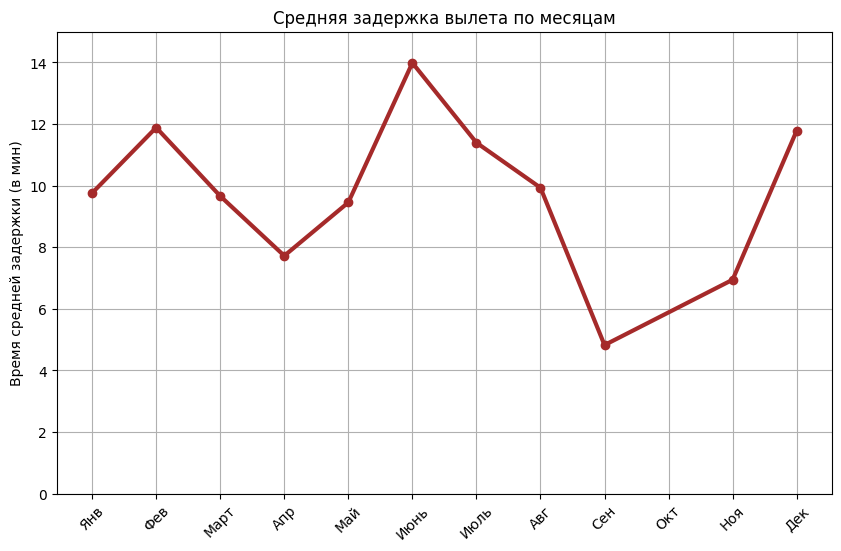

In [23]:
mdm = flights.groupby('MONTH')['DEPARTURE_DELAY'].mean()
print(mdm)

months = ['Янв', 'Фев', 'Март', 'Апр', 'Mай', 'Июнь', 'Июль', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

plt.figure(figsize = (10, 6))
plt.plot(mdm.index, mdm.values, marker = 'o', color = 'brown', linestyle = '-', linewidth = 3)
plt.title('Средняя задержка вылета по месяцам')
plt.ylabel('Время средней задержки (в мин)')
plt.xticks(range(1, 13), months, rotation = 45)
plt.ylim(0, 15)
plt.grid(True)
plt.show()

> Наибольшая задержка случается чаще зимой, что скорее всего связано с погодными условиями. Так же можно заметить, что летом задержка тоже больше среднего, возможно, из-за отпусков

# 6. Посмотрим из-за каких технических причин задержки чаще

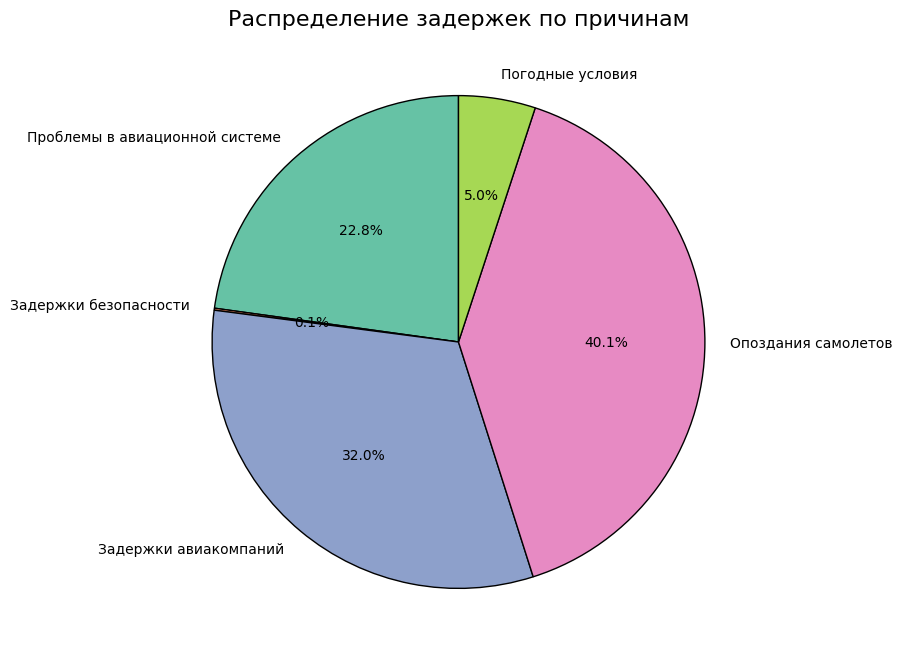

In [25]:
delays_reasons = flights[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].sum()

delays_reasons_out = ['Проблемы в авиационной системе', 'Задержки безопасности', 'Задержки авиакомпаний', 'Опоздания самолетов',
'Погодные условия']

plt.figure(figsize=(8, 8))
plt.pie(
    delays_reasons.values,
    labels=delays_reasons_out,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Set2"),
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
plt.title("Распределение задержек по причинам", fontsize=16)
plt.show()

> Главные причины задержек - опоздания самолетов и внутренние задержки авиакомпаний. Оказывается, погодные условия далеко не самый главный фактор

# Вывод
Задержки распределены неравномерно по аэропортам, авиакомпаниям и времени суток.

Имеются чёткие пиковые моменты — в начале и конце рабочей недели, а также в вечерние часы.

Некоторые аэропорты требуют дополнительного внимания из-за систематических сбоев.

Анализ помогает выявить "узкие места" в системе и может быть полезен для оптимизации расписаний и распределения ресурсов.